<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-03-28 21:02:13--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  51.0MB/s    in 4.2s    

2026-03-28 21:02:19 (47.8 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


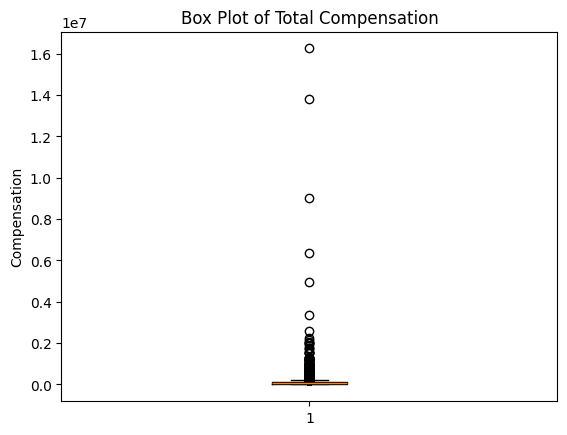

In [8]:
# your code goes here

# Query compensation
QUERY = """
SELECT ConvertedCompYearly
FROM main;
"""
df_comp = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_comp['ConvertedCompYearly'] = pd.to_numeric(df_comp['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_comp = df_comp.dropna(subset=['ConvertedCompYearly'])

# Plot box plot
plt.figure()
plt.boxplot(df_comp['ConvertedCompYearly'])
plt.title('Box Plot of Total Compensation')
plt.ylabel('Compensation')
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


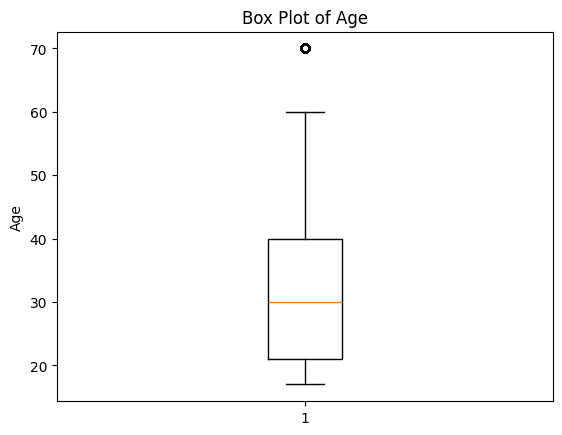

In [9]:
# your code goes here

# Query Age
QUERY = """
SELECT Age
FROM main;
"""
df_age = pd.read_sql_query(QUERY, conn)

# Map Age to numeric
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df_age['AgeNumeric'] = df_age['Age'].map(age_mapping)

# Plot
plt.figure()
plt.boxplot(df_age['AgeNumeric'].dropna())
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


/tmp/ipykernel_813/4109980946.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


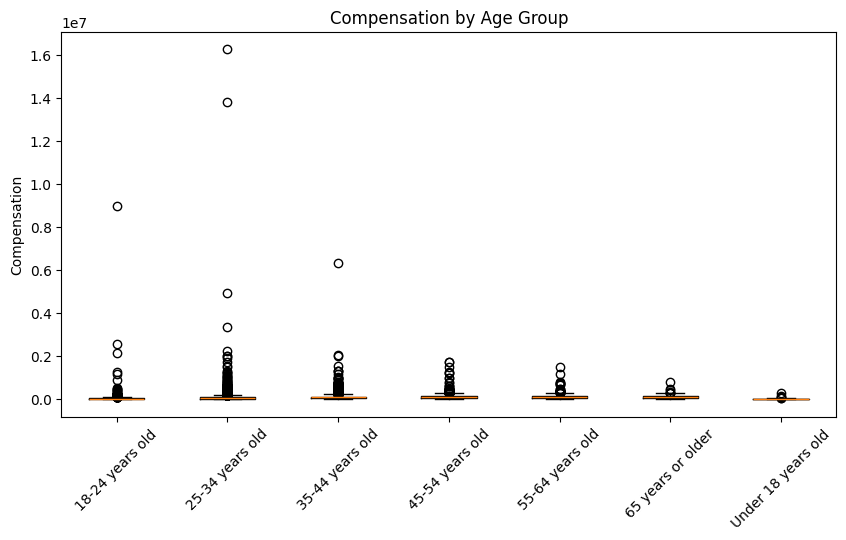

In [10]:
# your code goes here

# Query data
QUERY = """
SELECT Age, ConvertedCompYearly
FROM main;
"""
df = pd.read_sql_query(QUERY, conn)

# Map Age
df['AgeNumeric'] = df['Age'].map(age_mapping)

# Convert compensation
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Drop missing
df = df.dropna(subset=['AgeNumeric', 'ConvertedCompYearly'])

# Group data
grouped = [group['ConvertedCompYearly'].values for name, group in df.groupby('Age')]

# Labels
labels = df['Age'].dropna().unique()

# Plot
plt.figure(figsize=(10,5))
plt.boxplot(grouped, labels=labels)
plt.xticks(rotation=45)
plt.title('Compensation by Age Group')
plt.ylabel('Compensation')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


/tmp/ipykernel_813/1414901245.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


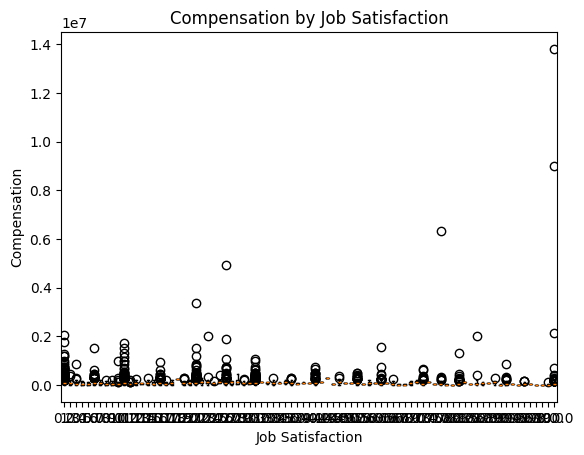

In [11]:
# your code goes here

# Query data
QUERY = """
SELECT JobSatPoints_6, ConvertedCompYearly
FROM main;
"""
df_job = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_job['ConvertedCompYearly'] = pd.to_numeric(df_job['ConvertedCompYearly'], errors='coerce')
df_job['JobSatPoints_6'] = pd.to_numeric(df_job['JobSatPoints_6'], errors='coerce')

# Drop missing
df_job = df_job.dropna()

# Group
grouped = [group['ConvertedCompYearly'].values for name, group in df_job.groupby('JobSatPoints_6')]

labels = sorted(df_job['JobSatPoints_6'].unique())

# Plot
plt.figure()
plt.boxplot(grouped, labels=labels)
plt.title('Compensation by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Compensation')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


/tmp/ipykernel_813/881046503.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


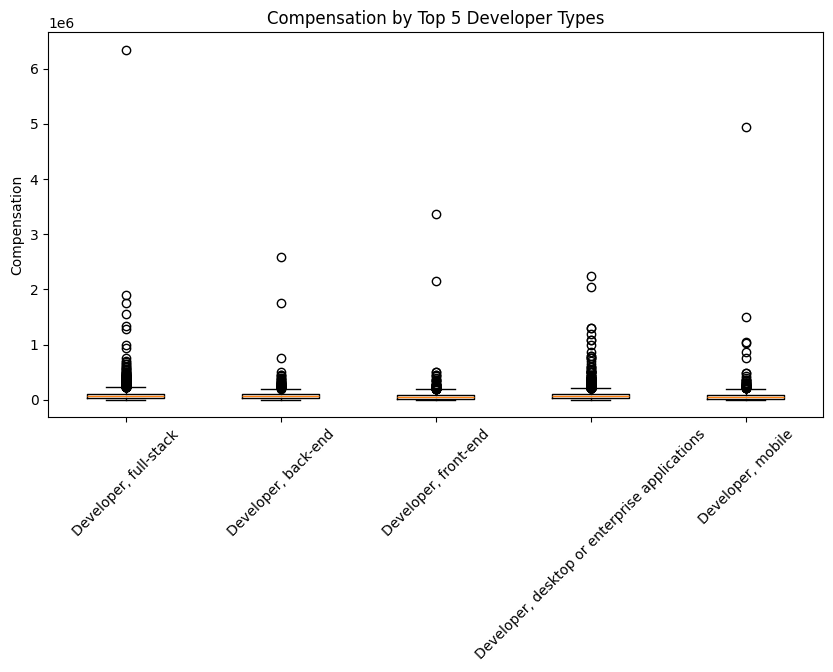

In [12]:
# your code goes here

# Query data
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main;
"""
df_dev = pd.read_sql_query(QUERY, conn)

# Convert compensation
df_dev['ConvertedCompYearly'] = pd.to_numeric(df_dev['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_dev = df_dev.dropna()

# Top 5 Dev Types
top5 = df_dev['DevType'].value_counts().nlargest(5).index

df_top = df_dev[df_dev['DevType'].isin(top5)]

# Group
grouped = [group['ConvertedCompYearly'].values for name, group in df_top.groupby('DevType')]

labels = top5

# Plot
plt.figure(figsize=(10,5))
plt.boxplot(grouped, labels=labels)
plt.xticks(rotation=45)
plt.title('Compensation by Top 5 Developer Types')
plt.ylabel('Compensation')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


/tmp/ipykernel_813/3955283847.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


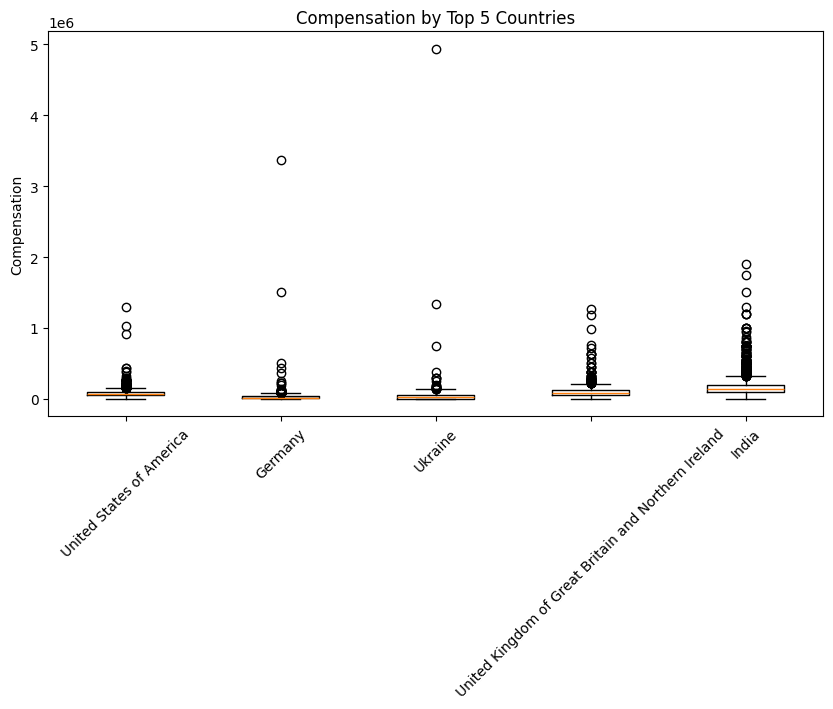

In [13]:
# your code goes here

# Query data
QUERY = """
SELECT Country, ConvertedCompYearly
FROM main;
"""
df_country = pd.read_sql_query(QUERY, conn)

# Convert compensation
df_country['ConvertedCompYearly'] = pd.to_numeric(df_country['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_country = df_country.dropna()

# Top 5 countries
top5 = df_country['Country'].value_counts().nlargest(5).index

df_top = df_country[df_country['Country'].isin(top5)]

# Group
grouped = [group['ConvertedCompYearly'].values for name, group in df_top.groupby('Country')]

labels = top5

# Plot
plt.figure(figsize=(10,5))
plt.boxplot(grouped, labels=labels)
plt.xticks(rotation=45)
plt.title('Compensation by Top 5 Countries')
plt.ylabel('Compensation')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


/tmp/ipykernel_813/944216505.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


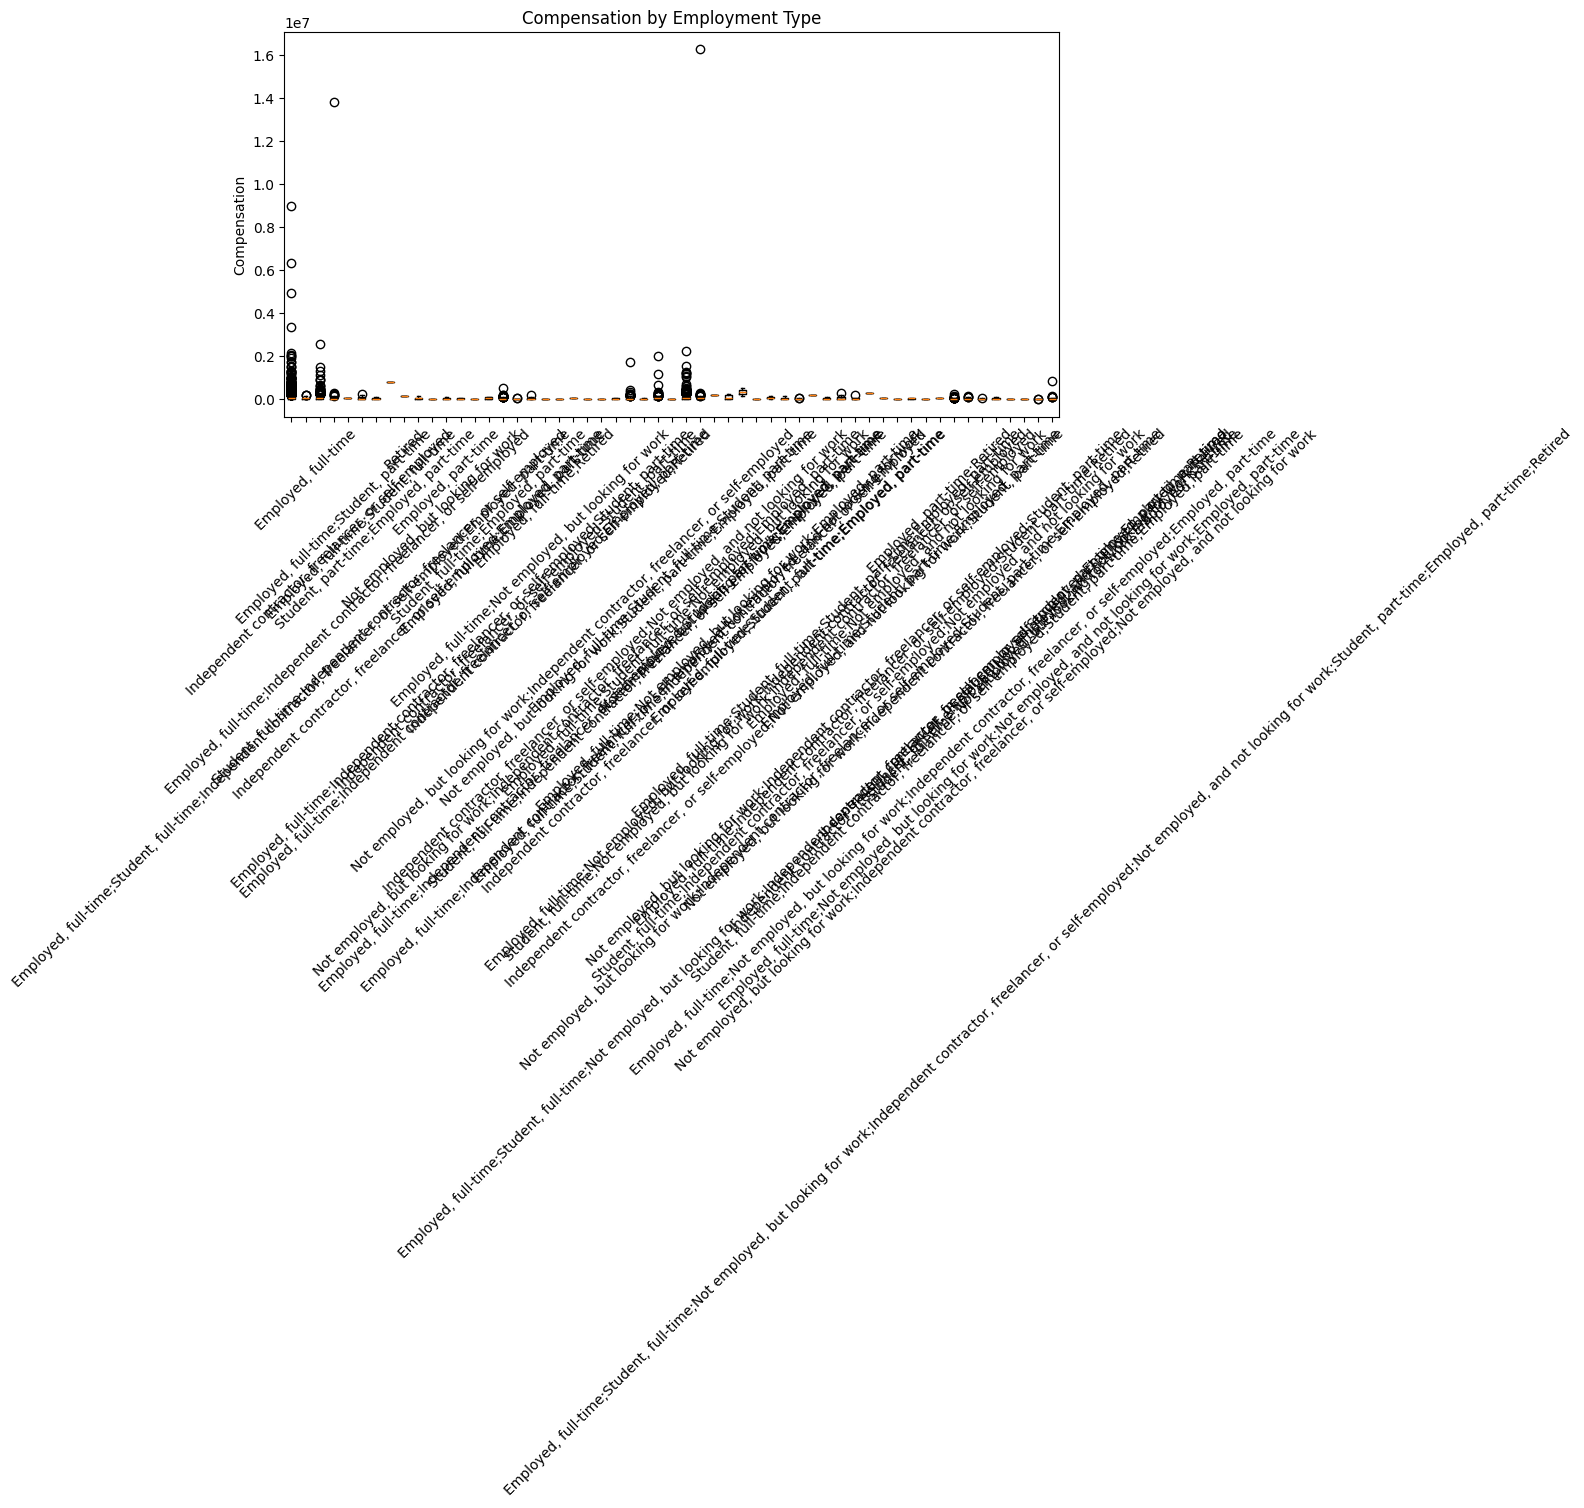

In [14]:
# your code goes here

# Query data
QUERY = """
SELECT Employment, ConvertedCompYearly
FROM main;
"""
df_emp = pd.read_sql_query(QUERY, conn)

# Convert compensation
df_emp['ConvertedCompYearly'] = pd.to_numeric(df_emp['ConvertedCompYearly'], errors='coerce')

# Drop missing
df_emp = df_emp.dropna()

# Group
grouped = [group['ConvertedCompYearly'].values for name, group in df_emp.groupby('Employment')]

labels = df_emp['Employment'].unique()

# Plot
plt.figure(figsize=(10,5))
plt.boxplot(grouped, labels=labels)
plt.xticks(rotation=45)
plt.title('Compensation by Employment Type')
plt.ylabel('Compensation')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


/tmp/ipykernel_813/1290302025.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=labels)


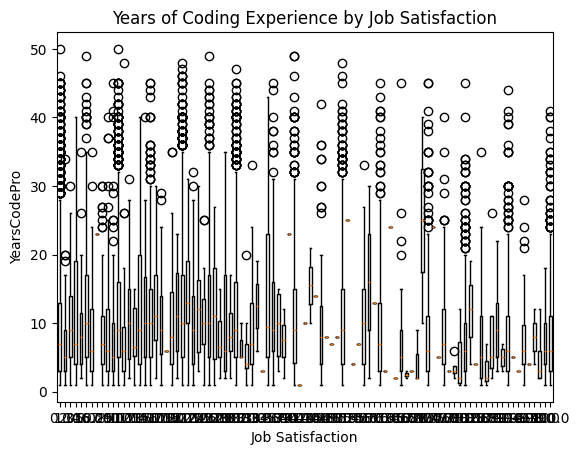

In [15]:
# your code goes here

# Query data
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main;
"""
df_y = pd.read_sql_query(QUERY, conn)

# Convert to numeric
df_y['YearsCodePro'] = pd.to_numeric(df_y['YearsCodePro'], errors='coerce')
df_y['JobSatPoints_6'] = pd.to_numeric(df_y['JobSatPoints_6'], errors='coerce')

# Drop missing
df_y = df_y.dropna()

# Group
grouped = [group['YearsCodePro'].values for name, group in df_y.groupby('JobSatPoints_6')]

labels = sorted(df_y['JobSatPoints_6'].unique())

# Plot
plt.figure()
plt.boxplot(grouped, labels=labels)
plt.title('Years of Coding Experience by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('YearsCodePro')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [16]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
